# DATASCI 503, Homework 4: Classification

This assignment covers Linear Discriminant Analysis (LDA), Quadratic Discriminant Analysis (QDA), and logistic regression for classification problems.

In [47]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sympy import solve, symbols

warnings.filterwarnings("ignore")

---

**Problem 1 (ISLP Ch 4, Exercise 2):** LDA Discriminant Function Derivation

It was stated in the text that classifying an observation to the class for which

$$p_k(x) = \frac{\pi_k \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{1}{2\sigma^2}(x - \mu_k)^2\right)}{\sum_{l=1}^{K} \pi_l \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{1}{2\sigma^2}(x - \mu_l)^2\right)}$$

is largest is equivalent to classifying an observation to the class for which

$$\delta_k(x) = x \cdot \frac{\mu_k}{\sigma^2} - \frac{\mu_k^2}{2\sigma^2} + \log(\pi_k)$$

is largest. Prove that this is the case. In other words, under the assumption that the observations in the $k$th class are drawn from a $N(\mu_k, \sigma^2)$ distribution, the Bayes classifier assigns an observation to the class for which the discriminant function is maximized.

Classify $x$ by maximizing the posterior $p_k(x)=\Pr(Y=k\mid X=x)=\frac{\pi_k f_k(x)}{\sum_{l=1}^K \pi_l f_l(x)}$ where $f_k(x)=\frac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\frac{(x-\mu_k)^2}{2\sigma^2}\right)$.  
For fixed $x$, the denominator does not depend on $k$, so $\arg\max_k p_k(x)=\arg\max_k \pi_k f_k(x)$.  
Apply the increasing transform $\log$: $\arg\max_k \pi_k f_k(x)=\arg\max_k\{\log\pi_k+\log f_k(x)\}$.  
Now $\log f_k(x)=-\frac12\log(2\pi)-\log\sigma-\frac{(x-\mu_k)^2}{2\sigma^2}$; drop constants in $k$ to maximize $\log\pi_k-\frac{(x-\mu_k)^2}{2\sigma^2}$.  
Expand $-\frac{(x-\mu_k)^2}{2\sigma^2}=-\frac{x^2}{2\sigma^2}+\frac{x\mu_k}{\sigma^2}-\frac{\mu_k^2}{2\sigma^2}$; drop $-\frac{x^2}{2\sigma^2}$ (independent of $k$).  
Thus the Bayes classifier chooses the class maximizing $\delta_k(x)=x\cdot\frac{\mu_k}{\sigma^2}-\frac{\mu_k^2}{2\sigma^2}+\log(\pi_k)$, as claimed.

---

**Problem 2 (ISLP Ch 4, Exercise 3):** QDA is Quadratic

This problem relates to the QDA model, in which the observations within each class are drawn from a normal distribution with a class-specific mean vector and a class-specific covariance matrix. We consider the simple case where $p = 1$; i.e. there is only one feature.

Suppose that we have $K$ classes, and that if an observation belongs to the $k$th class then $X$ comes from a one-dimensional normal distribution, $X \sim N(\mu_k, \sigma_k^2)$. Recall that the density function for the one-dimensional normal distribution is given by

$$f_k(x) = \frac{1}{\sqrt{2\pi}\sigma_k} \exp\left(-\frac{1}{2\sigma_k^2}(x - \mu_k)^2\right).$$

Prove that in this case, the Bayes classifier is *not* linear. Argue that it is in fact quadratic.

*Hint: For this problem, you should follow the arguments laid out in Problem 1, but without making the assumption that $\sigma_1^2 = \cdots = \sigma_K^2$.*

Bayes assigns $x$ to the class maximizing the posterior $p_k(x)=\Pr(Y=k\mid X=x)$, and for fixed $x$ the denominator is common, so $\arg\max_k p_k(x)=\arg\max_k \pi_k f_k(x)=\arg\max_k\{\log\pi_k+\log f_k(x)\}$. With $X\mid(Y=k)\sim N(\mu_k,\sigma_k^2)$, $\log f_k(x)=-\tfrac12\log(2\pi)-\log\sigma_k-\frac{(x-\mu_k)^2}{2\sigma_k^2}$, so dropping the constant $-\tfrac12\log(2\pi)$ gives the QDA discriminant $\delta_k(x)=\log\pi_k-\log\sigma_k-\frac{(x-\mu_k)^2}{2\sigma_k^2}$. Expanding, $\delta_k(x)=-\frac{1}{2\sigma_k^2}x^2+\frac{\mu_k}{\sigma_k^2}x-\frac{\mu_k^2}{2\sigma_k^2}+\log\pi_k-\log\sigma_k$, which is quadratic in $x$.

Unlike LDA, the $x^2$ term cannot be dropped because its coefficient $-\frac{1}{2\sigma_k^2}$ depends on $k$ when the variances differ; therefore the Bayes rule is not linear. For two classes $k,l$, the decision boundary solves $\delta_k(x)=\delta_l(x)$, i.e.
$$
\left(\frac{1}{\sigma_l^2}-\frac{1}{\sigma_k^2}\right)x^2
+2\left(\frac{\mu_k}{\sigma_k^2}-\frac{\mu_l}{\sigma_l^2}\right)x
+\left(\frac{\mu_l^2}{\sigma_l^2}-\frac{\mu_k^2}{\sigma_k^2}\right)
+2\log\left(\frac{\pi_k\sigma_l}{\pi_l\sigma_k}\right)=0,
$$
a quadratic equation (reducing to linear only if $\sigma_k^2=\sigma_l^2$).

---

**Problem 3 (ISLP Ch 4, Exercise 5a, 5b, and 5d):** LDA vs QDA Performance

We now examine the differences between LDA and QDA.

(a) If the Bayes decision boundary is linear, do we expect LDA or QDA to perform better on the training set? On the test set?

If the Bayes decision boundary is linear, QDA will typically do at least as well on the *training* set (it is more flexible, so it can fit the training data better). On the *test* set, we typically expect LDA to perform better because it matches the true linear structure and has lower variance (QDA estimates more parameters, so it can overfit).

(b) If the Bayes decision boundary is non-linear, do we expect LDA or QDA to perform better on the training set? On the test set?

If the Bayes decision boundary is non-linear, QDA will typically perform better on the *training* set (greater flexibility). On the *test* set, QDA is often better *when there is enough data* to estimate the class-specific variances/covariances well; with limited data, LDA can still outperform due to lower variance even though it is biased.

(c) True or False: Even if the Bayes decision boundary for a given problem is linear, we will probably achieve a superior test error rate using QDA rather than LDA because QDA is flexible enough to model a linear decision boundary. Justify your answer.

False. While QDA can represent a linear boundary as a special case, its extra flexibility generally increases estimation variance; if the true boundary is linear, that added variance can hurt test performance, so LDA will often have lower test error.

---

**Problem 4 (ISLP Ch 4, Exercise 7):** Dividend Prediction

Suppose that we wish to predict whether a given stock will issue a dividend this year ("Yes" or "No") based on $X$, last year's percent profit. We examine a large number of companies and discover that the mean value of $X$ for companies that issued a dividend was $\bar{X} = 10$, while the mean for those that didn't was $\bar{X} = 0$. In addition, the variance of $X$ for these two sets of companies was $\hat{\sigma}^2 = 36$. Finally, 80% of companies issued dividends. Assuming that $X$ follows a normal distribution, predict the probability that a company will issue a dividend this year given that its percentage profit was $X = 4$ last year.

*Hint: Recall that the density function for a normal random variable is $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-(x-\mu)^2 / 2\sigma^2}$. You will need to use Bayes' theorem.*

In [48]:
x = 4
mu_yes, mu_no = 10, 0
sigma = 6  # since variance = 36
pi_yes = 0.8

num = pi_yes * norm.pdf(x, loc=mu_yes, scale=sigma)
den = num + (1 - pi_yes) * norm.pdf(x, loc=mu_no, scale=sigma)
prob_dividend = num / den

print(f"Probability of dividend given X=4: {prob_dividend:.4f}")

Probability of dividend given X=4: 0.7519


In [49]:
# Test assertions
assert 0.75 < prob_dividend < 0.76, f"Expected ~0.7519, got {prob_dividend}"
print("All tests passed!")

All tests passed!


## LDA Decision Boundary

Suppose you have one continuous predictor $X$ and a binary categorical response $Y$, which can take values 1 or 2. Suppose you collected training data from the two classes and obtained class-specific sample means $\hat{\mu}_1 = -1$ and $\hat{\mu}_2 = 3$, along with the pooled variance estimate over the two classes, $\hat{\sigma}^2 = 1$.

---

**Problem 5 (a):** Equal Priors

Assume equal class priors and derive the LDA classification rule for this problem. Using `scipy.stats.norm.pdf` to compute the necessary probability density functions, show both of the estimated class-conditional densities in the same plot. Also show the estimated Bayes decision boundary in this plot. Make sure you label the axes.

Let $c$ denote the position of the decision boundary. Store the numerical value of $c$ in a variable called `boundary_c`.

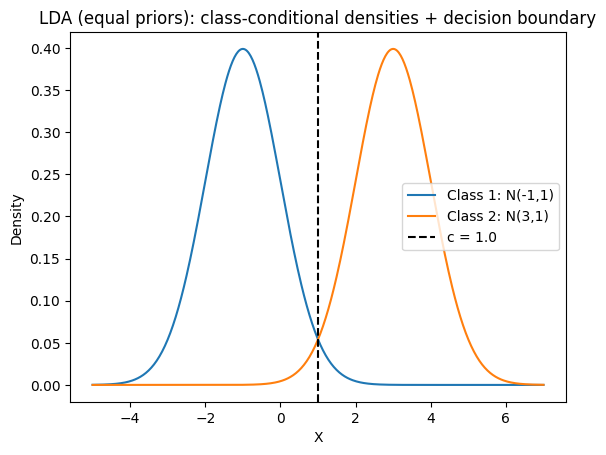

Decision boundary position: c = 1.0


In [50]:
# Plot class-conditional densities and compute decision boundary
mu1, mu2 = -1, 3
sigma = 1.0  # pooled sd since sigma^2 = 1
boundary_c = (mu1 + mu2) / 2  # equal priors => midpoint for equal-variance normals

xs = np.linspace(mu1 - 4 * sigma, mu2 + 4 * sigma, 500)
plt.plot(xs, norm.pdf(xs, loc=mu1, scale=sigma), label="Class 1: N(-1,1)")
plt.plot(xs, norm.pdf(xs, loc=mu2, scale=sigma), label="Class 2: N(3,1)")
plt.axvline(boundary_c, color="k", linestyle="--", label=f"c = {boundary_c}")
plt.xlabel("X")
plt.ylabel("Density")
plt.title("LDA (equal priors): class-conditional densities + decision boundary")
plt.legend()
plt.show()

print(f"Decision boundary position: c = {boundary_c}")

In [51]:
# Test assertions
assert boundary_c == 1.0, f"Expected boundary at 1.0, got {boundary_c}"
print("All tests passed!")

All tests passed!


**Problem 5 (b)** Unequal Priors (Conceptual)

Suppose the estimates were obtained from 100 training points, among which 40 were from class 1 and 60 were from class 2. Suppose now you will estimate class priors from data.

Without calculating the new boundary $\hat{c}$, would you expect it to be the same as, less than, or greater than $c$? Explain your reasoning.

Since $\hat{\pi}_2=0.6$ is larger than $\hat{\pi}_1=0.4$, class 2 is more likely a priori. With LDA and $\mu_2>\mu_1$, the rule has the form "predict class 2 when $x>c$". Increasing the prior probability of class 2 should make the classifier predict class 2 more often, so the region where we predict class 2 must expand. That happens by moving the cutoff to the left, i.e. shifting the decision boundary toward class 1. Therefore the new boundary satisfies $\hat{c}<c$ (and under equal priors, $c=(\mu_1+\mu_2)/2=1$).

**Problem 5 (c)** Calculate Boundary with Unequal Priors

Now calculate the new boundary value $\hat{c}$ using the priors estimated from the data (40 from class 1, 60 from class 2). Store your answer in a variable called `boundary_c_hat`.

In [52]:
# Calculate boundary with unequal priors

mu1, mu2 = -1, 3
sigma2 = 1.0  # pooled variance estimate (common variance in LDA)
pi1, pi2 = 40/100, 60/100  # estimated class priors from counts

# boundary_c_hat solves: pi1 * Normal(x | mu1, sigma2) = pi2 * Normal(x | mu2, sigma2)
# This is the point where the two LDA discriminant scores are equal
# Closed form: c_hat = (mu1 + mu2)/2 - (sigma2/(mu1 - mu2)) * log(pi1/pi2)
boundary_c_hat = (mu1 + mu2) / 2 - (sigma2 / (mu1 - mu2)) * np.log(pi1 / pi2)

print(f"New decision boundary: c_hat = {boundary_c_hat:.4f}")

New decision boundary: c_hat = 0.8986


In [53]:
# Test assertions
assert 0.89 < boundary_c_hat < 0.91, f"Expected ~0.899, got {boundary_c_hat}"
assert boundary_c_hat < 1.0, "boundary_c_hat should be less than 1.0"
print("All tests passed!")

All tests passed!


**Problem 5 (d)** LDA vs QDA Recommendation

Suppose in addition to the pooled covariance value $\hat{\sigma}^2 = 1$, I now tell you the individual class-specific covariances were estimated as $\hat{\sigma}_1^2 = 0.25$ and $\hat{\sigma}_2^2 = 1.5$.

Based on this new information, would you recommend using LDA or QDA, and why?

I would recommend **QDA**.

Because the class-specific variance estimates differ substantially ($\hat{\sigma}_1^2=0.25$ vs. $\hat{\sigma}_2^2=1.5$), the equal-variance assumption required by LDA (i.e., $\sigma_1^2=\sigma_2^2$) is likely violated. QDA allows $\sigma_1^2\neq\sigma_2^2$, which generally yields a **quadratic** decision boundary, whereas LDA would force a linear boundary and may be misspecified here.

**Problem 5 (e)** QDA Decision Boundary

Derive the QDA rule if $\hat{\sigma}_1^2 = 0.25$ and $\hat{\sigma}_2^2 = 1.5$, $\hat{\mu}_1 = -1$ and $\hat{\mu}_2 = 3$, assuming equal class priors. Calculate the numerical values for the decision boundary. Store the two boundary values in a list called `qda_boundaries` (sorted from smallest to largest).

In [54]:
# Calculate QDA decision boundary

import numpy as np

# Given parameter estimates
mu1, mu2 = -1.0, 3.0
var1, var2 = 0.25, 1.5
pi1, pi2 = 0.5, 0.5

# Decision boundary solves: log(pi1 * f1(x)) = log(pi2 * f2(x))
# With different variances this becomes a quadratic equation in x

a = (1.0 / var2) - (1.0 / var1)
b = (-2.0 * mu2 / var2) + (2.0 * mu1 / var1)
c = (mu2**2 / var2) - (mu1**2 / var1) + np.log(var2 / var1) + 2.0 * np.log(pi1 / pi2)

roots = np.roots([a, b, c])

# Keep real roots only, then sort
qda_boundaries = sorted([float(r.real) for r in roots if abs(r.imag) < 1e-10])

print(f"QDA decision boundaries: {qda_boundaries}")


QDA decision boundaries: [-3.8922542485960965, 0.2922542485960965]


In [55]:
# Test assertions
assert len(qda_boundaries) == 2, "Should have two boundary points"
print("All tests passed!")

All tests passed!


## Stock Market Prediction

The `Smarket` dataset consists of percentage returns for the S&P 500 stock index over 1,250 days, from the beginning of 2001 until the end of 2005. For each date, we have recorded the percentage returns for each of the five previous trading days (`Lag1` through `Lag5`), the trading `Volume` (in billions of shares) for the previous trading day, and the return and direction (Up or Down) of the market on the date in question (`Today` and `Direction`).

In [56]:
# Load the Smarket data
smarket = pd.read_csv("./data/Smarket.csv")
smarket.head()

,Unnamed: 0,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


---

**Problem 6 (a):** Exploratory Data Analysis

Produce some numerical and graphical summaries of the `smarket` data. Do there appear to be any patterns? Create at least one visualization (e.g., boxplots comparing Up vs Down days).

There appears to be the strongest association between `Today` and `Direction`. 

,Unnamed: 0,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000,1250
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Up
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,648
mean,624.500000,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138,NaN
std,360.988227,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334,NaN
min,0.000000,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000,NaN
25%,312.250000,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500,NaN
50%,624.500000,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500,NaN
75%,936.750000,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750,NaN


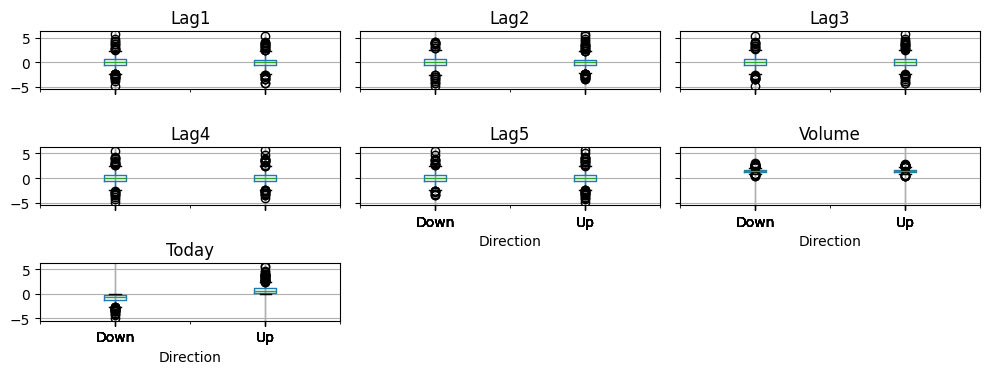

In [57]:
# Numerical summary
display(smarket.describe(include="all"))

# Boxplots comparing Up vs Down days (numeric columns only)
cols = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]  # exclude "Direction"
ax = smarket.boxplot(column=cols, by="Direction", figsize=(10, 4))

plt.suptitle("")  # remove automatic grouped title
plt.title("Smarket numeric variables by Direction")
plt.xlabel("Direction")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [58]:
# Test assertions
assert True, "Plot should be created above"
print("All tests passed!")

All tests passed!


---

**Problem 6 (b):** LDA on Stock Market Data

Fit an LDA model using training data from 2001 to 2004, with `Direction` as the response and `Lag1` and `Lag2` as predictors. Use the model to predict on the held-out test data (2005). Store the test accuracy in a variable called `lda_accuracy`.

In [59]:
# Fit LDA model and evaluate on test set

# train: 2001-2004, test: 2005
train_mask = smarket['Year'] < 2005
test_mask = smarket['Year'] == 2005 

x_train_sm = smarket.loc[train_mask, ["Lag1", "Lag2"]]
y_train_sm = smarket.loc[train_mask, "Direction"]

x_test_sm = smarket.loc[test_mask, ["Lag1", "Lag2"]]
y_test_sm = smarket.loc[test_mask, "Direction"]

lda = LinearDiscriminantAnalysis() 
lda.fit(x_train_sm, y_train_sm)

y_pred_lda = lda.predict(x_test_sm)
lda_accuracy = accuracy_score(y_test_sm, y_pred_lda)

print(f"LDA Test Accuracy: {lda_accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_sm, y_pred_lda))

LDA Test Accuracy: 0.5595

Confusion Matrix:
[[ 35  76]
 [ 35 106]]


In [60]:
# Test assertions
assert 0.5 < lda_accuracy < 0.6, f"Expected accuracy around 0.56, got {lda_accuracy}"
print("All tests passed!")

All tests passed!


---

**Problem 6 (c):** QDA on Stock Market Data

Repeat the analysis using QDA instead of LDA. Store the test accuracy in a variable called `qda_accuracy`.

In [61]:
# Fit QDA model and evaluate on test set
qda = QuadraticDiscriminantAnalysis()
qda.fit(x_train_sm, y_train_sm)

y_pred_qda = qda.predict(x_test_sm)
qda_accuracy = accuracy_score(y_test_sm, y_pred_qda)

print(f"QDA Test Accuracy: {qda_accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_sm, y_pred_qda))

QDA Test Accuracy: 0.5992

Confusion Matrix:
[[ 30  81]
 [ 20 121]]


In [62]:
# Test assertions
assert 0.59 < qda_accuracy < 0.61, f"Expected accuracy around 0.60, got {qda_accuracy}"
print("All tests passed!")

All tests passed!


## Auto MPG Classification

In this problem, you will develop a model to predict whether a given car will be classified as having high or low gas mileage based on the Auto dataset.

In [63]:
# Load the Auto data
auto_df = pd.read_csv("./data/auto_nonan.csv", index_col=0).set_index("name")
auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [64]:
auto_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

---

**Problem 7 (a):** Create Binary Variable

Create a binary variable `mpg01` that equals 1 if the value of `mpg` for that car is above 25, and 0 otherwise. Add this variable as a new column to your data frame.

In [65]:
# Create mpg01 column
auto_df["mpg01"] = (auto_df["mpg"] > 25).astype(int)

# quick check 
print(auto_df["mpg01"].value_counts().sort_index())

mpg01
0    236
1    156
Name: count, dtype: int64


In [66]:
# Test assertions
assert "mpg01" in auto_df.columns, "mpg01 column not found"
assert auto_df["mpg01"].isin([0, 1]).all(), "mpg01 should only contain 0 and 1"
print("All tests passed!")

All tests passed!


---

**Problem 7 (b):** Exploratory Analysis

Make some exploratory plots to investigate the association between `mpg01` and other variables. Besides `mpg` itself, which four quantitative features do you think are most likely to be useful in predicting `mpg01`? Defend your argument with plots (e.g., side-by-side boxplots).

The four quantitative variables most visually associated with `mpg01` are `cylinders`, `displacement`, `horsepower`, and `weight`. However, additional analysis is required. 

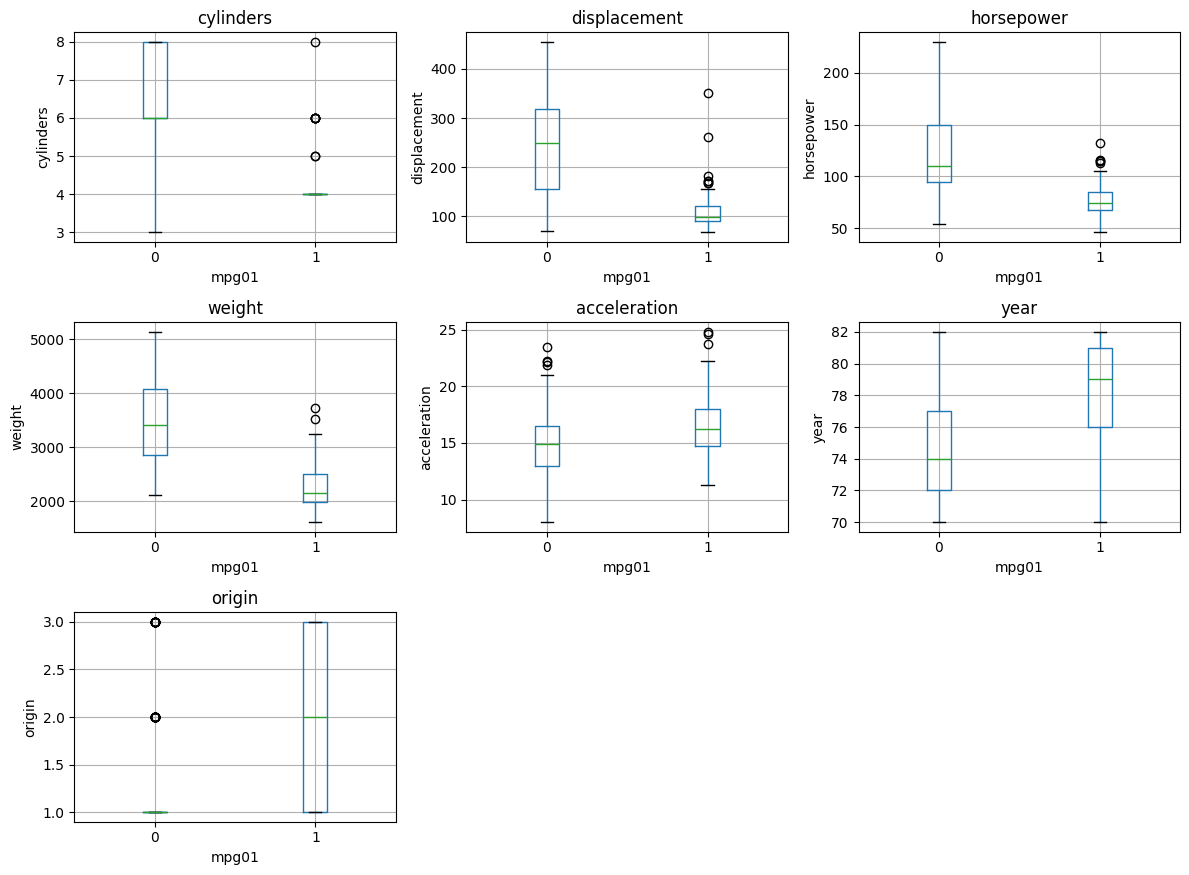

In [67]:
cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year", "origin"]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    auto_df.boxplot(column=col, by="mpg01", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("mpg01")
    ax.set_ylabel(col)

# hide any unused subplots 
for ax in axes[len(cols):]:
    ax.axis("off")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [68]:
# Test assertions
assert True, "Plot should be created above"
print("All tests passed!")

All tests passed!


---

**Problem 7 (c):** Train/Test Split

Split the data into training and test sets using `train_test_split` with:
- `random_state=123`
- `train_size=0.8`
- `stratify` set to the values of `mpg01`

Store the number of training samples where `mpg01` is 1 in a variable called `n_mpg01_train`.

In [69]:
# Split data into train and test sets
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year", "origin"]
X = auto_df[features]
y = auto_df["mpg01"]

x_train_auto, x_test_auto, y_train_auto, y_test_auto = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=123,
    stratify=y,
)

n_mpg01_train = int((y_train_auto == 1).sum())
print("n_mpg01_train =", n_mpg01_train)

n_mpg01_train = 125


In [70]:
# Test assertions
assert n_mpg01_train == 125, f"Expected 125, got {n_mpg01_train}"
assert len(x_train_auto) == 313, "Training set should have 313 samples"
print("All tests passed!")

All tests passed!


---

**Problem 7 (d):** LDA on Auto Data

Fit an LDA model on the training data using the four selected features. Report the misclassification rate on both training and test data. Store the test misclassification rate in a variable called `lda_misclass_test`.

Choose two of the four variables from part (b), and make a scatterplot of the training data points. Use different colors to indicate the true values of `mpg01` and different plotting symbols (e.g., `+` and `o`) to indicate predicted values.

LDA Training misclassification rate: 0.1470
LDA Test misclassification rate:     0.2025


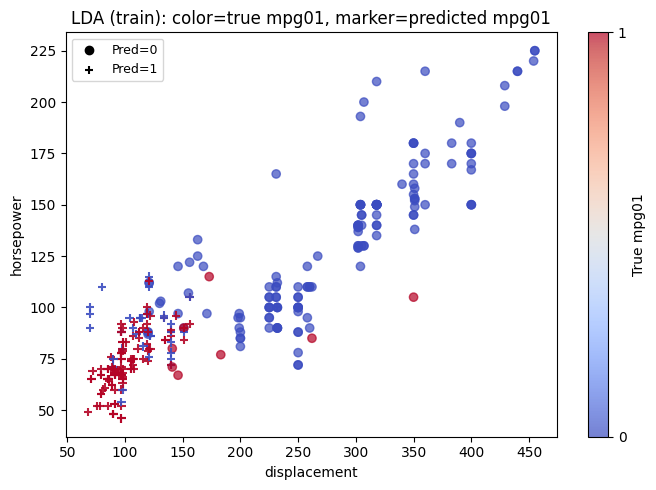

In [71]:
# Fit LDA model and create visualization

# Use the 4 selected features
lda_features = ["cylinders", "displacement", "weight", "horsepower"]

X_train = x_train_auto[lda_features]
X_test = x_test_auto[lda_features]

lda_auto = LinearDiscriminantAnalysis()
lda_auto.fit(X_train, y_train_auto)

# predictions
y_pred_train = lda_auto.predict(X_train)
y_pred_test = lda_auto.predict(X_test)

# misclassification rates
lda_misclass_train = 1.0 - accuracy_score(y_train_auto, y_pred_train)
lda_misclass_test = 1.0 - accuracy_score(y_test_auto, y_pred_test)

print(f"LDA Training misclassification rate: {lda_misclass_train:.4f}")
print(f"LDA Test misclassification rate:     {lda_misclass_test:.4f}")

# --- Problem 7(d) scatter (simpler legend via colorbar) ---
xvar, yvar = "displacement", "horsepower"
x = X_train[xvar].to_numpy()
y = X_train[yvar].to_numpy()
true = y_train_auto.to_numpy()
pred = y_pred_train

plt.figure(figsize=(7, 5))

m0 = pred == 0
m1 = pred == 1

s0 = plt.scatter(x[m0], y[m0], c=true[m0], cmap="coolwarm", vmin=0, vmax=1, marker="o", alpha=0.7)
plt.scatter(x[m1], y[m1], c=true[m1], cmap="coolwarm", vmin=0, vmax=1, marker="+", alpha=0.9)

plt.xlabel(xvar)
plt.ylabel(yvar)
plt.title("LDA (train): color=true mpg01, marker=predicted mpg01")

plt.colorbar(s0, ticks=[0, 1], label="True mpg01")
plt.scatter([], [], c="k", marker="o", label="Pred=0")
plt.scatter([], [], c="k", marker="+", label="Pred=1")
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [72]:
# Test assertions
assert 0.1 < lda_misclass_test < 0.25, f"Expected ~0.20, got {lda_misclass_test}"
print("All tests passed!")

All tests passed!


---

**Problem 7 (e):** QDA on Auto Data

Repeat part (d) using QDA. Fit a QDA model on training data, calculate training and test misclassification rates, and make a scatterplot analogous to part (d) using the same two variables. Store the test misclassification rate in a variable called `qda_misclass_test`.

QDA Training misclassification rate: 0.1374
QDA Test misclassification rate:     0.1772


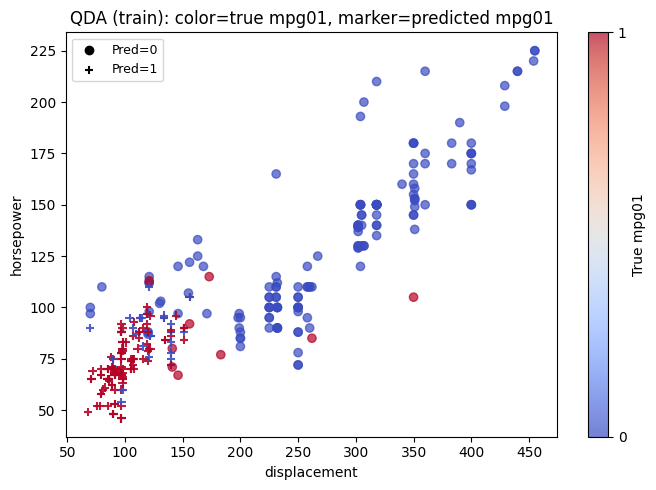

In [73]:
# Problem 7(e): QDA on Auto data (use SAME split + SAME 4 features + SAME 2 plotting vars as 7(d))
qda_features = lda_features  # use the same 4 features you used for LDA in 7(d)

X_train_qda = x_train_auto[qda_features]
X_test_qda = x_test_auto[qda_features]

qda_auto = QuadraticDiscriminantAnalysis()
qda_auto.fit(X_train_qda, y_train_auto)

y_pred_train_qda = qda_auto.predict(X_train_qda)
y_pred_test_qda = qda_auto.predict(X_test_qda)

qda_misclass_train = 1.0 - accuracy_score(y_train_auto, y_pred_train_qda)
qda_misclass_test = 1.0 - accuracy_score(y_test_auto, y_pred_test_qda)

print(f"QDA Training misclassification rate: {qda_misclass_train:.4f}")
print(f"QDA Test misclassification rate:     {qda_misclass_test:.4f}")

# scatterplot analogous to 7(d): color=true mpg01 (via colorbar), marker=predicted mpg01
x = X_train_qda[xvar].to_numpy()
y = X_train_qda[yvar].to_numpy()
true = y_train_auto.to_numpy()
pred = y_pred_train_qda

plt.figure(figsize=(7, 5))

m0 = pred == 0
m1 = pred == 1

sc = plt.scatter(
    x[m0], y[m0],
    c=true[m0], cmap="coolwarm", vmin=0, vmax=1,
    marker="o", alpha=0.7
)
plt.scatter(
    x[m1], y[m1],
    c=true[m1], cmap="coolwarm", vmin=0, vmax=1,
    marker="+", alpha=0.9
)

plt.xlabel(xvar)
plt.ylabel(yvar)
plt.title("QDA (train): color=true mpg01, marker=predicted mpg01")

plt.colorbar(sc, ticks=[0, 1], label="True mpg01")
plt.scatter([], [], c="k", marker="o", label="Pred=0")
plt.scatter([], [], c="k", marker="+", label="Pred=1")
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [74]:
# Test assertions
assert 0.15 < qda_misclass_test < 0.2, f"Expected ~0.18, got {qda_misclass_test}"
print("All tests passed!")

All tests passed!


---

**Problem 7 (f):** Compare LDA and QDA

Compare and contrast the performance of LDA and QDA. What do your results suggest about the class-specific covariances?

> *Your answer here*

---

**Problem 7 (g):** Logistic Regression

Repeat part (d) using logistic regression. Fit a logistic regression model on training data, calculate training and test misclassification rates, and make a scatterplot analogous to part (d) using the same two variables. Store the test misclassification rate in a variable called `logistic_misclass_test`.

Logistic Training misclassification rate: 0.1214
Logistic Test misclassification rate:     0.1519


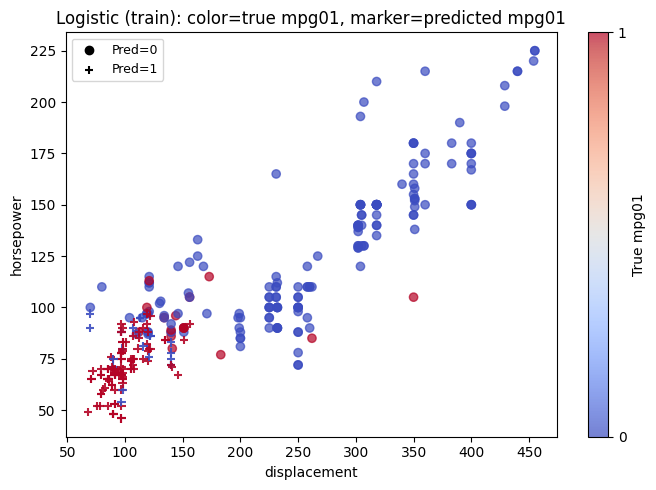

In [75]:
# Problem 7(g): Logistic Regression (use same split + same 4 features + same xvar/yvar as 7(d))
log_features = lda_features  # reuse the same 4 selected features from part (d)

X_train_log = x_train_auto[log_features]
X_test_log = x_test_auto[log_features]

log_model = LogisticRegression(max_iter=5000)  # default solver is fine for this size
log_model.fit(X_train_log, y_train_auto)

y_pred_train_log = log_model.predict(X_train_log)
y_pred_test_log = log_model.predict(X_test_log)

logistic_misclass_train = 1.0 - accuracy_score(y_train_auto, y_pred_train_log)
logistic_misclass_test = 1.0 - accuracy_score(y_test_auto, y_pred_test_log)

print(f"Logistic Training misclassification rate: {logistic_misclass_train:.4f}")
print(f"Logistic Test misclassification rate:     {logistic_misclass_test:.4f}")

# Scatterplot analogous to part (d): color=true mpg01 (via colorbar), marker=predicted mpg01
x = X_train_log[xvar].to_numpy()
y = X_train_log[yvar].to_numpy()
true = y_train_auto.to_numpy()
pred = y_pred_train_log

plt.figure(figsize=(7, 5))

m0 = pred == 0
m1 = pred == 1

sc = plt.scatter(
    x[m0], y[m0],
    c=true[m0], cmap="coolwarm", vmin=0, vmax=1,
    marker="o", alpha=0.7
)
plt.scatter(
    x[m1], y[m1],
    c=true[m1], cmap="coolwarm", vmin=0, vmax=1,
    marker="+", alpha=0.9
)

plt.xlabel(xvar)
plt.ylabel(yvar)
plt.title("Logistic (train): color=true mpg01, marker=predicted mpg01")
plt.colorbar(sc, ticks=[0, 1], label="True mpg01")

plt.scatter([], [], c="k", marker="o", label="Pred=0")
plt.scatter([], [], c="k", marker="+", label="Pred=1")
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
# Test assertions
assert 0.1 < logistic_misclass_test < 0.2, f"Expected ~0.15, got {logistic_misclass_test}"
print("All tests passed!")

All tests passed!


---

**Problem 7 (h):** Logistic Regression Probability Estimation

Using your fitted logistic regression model, estimate the probability of a car having `mpg` above 25 if its values for the four predictors are all at the corresponding median values in the training dataset. Store this probability in a variable called `prob_median_logistic`.

In [77]:
# Estimate probability at median predictor values
median_vals = X_train_log.median()
X_median = pd.DataFrame([median_vals], columns = log_features)

# first and only row; col 1 for class 1 
prob_median_logistic = float(log_model.predict_proba(X_median)[0,1]) 

print(f"Probability mpg > 25 at median predictors (Logistic): {prob_median_logistic:.4f}")


Probability mpg > 25 at median predictors (Logistic): 0.3737


In [78]:
# Test assertions
assert 0 <= prob_median_logistic <= 1, "Probability should be between 0 and 1"
print("All tests passed!")

All tests passed!


---

**Problem 7 (i):** K-Nearest Neighbors

Fit KNN models for various values of K (from 1 to 35). Plot the training and test classification error vs K (or 1/K; if you use 1/K, make sure the x-axis is on the log scale). Which K gives the best performance on the training data? On the test data? Which K would you use? Store your chosen K in a variable called `best_k`.

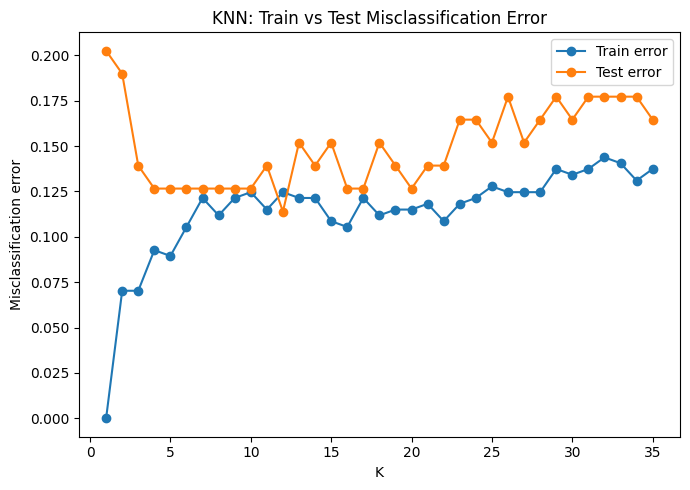

Best K based on training error: 1
Best K based on test error: 12


In [79]:
# Fit KNN models for various K
knn_features = lda_features  # assumes lda_features already defined in 7(d)
X_train = x_train_auto[knn_features].to_numpy()
X_test = x_test_auto[knn_features].to_numpy()
y_train = y_train_auto.to_numpy()
y_test = y_test_auto.to_numpy()

# simple standardization (important for KNN) using TRAIN stats only
mu = X_train.mean(axis=0)
sd = X_train.std(axis=0)
sd[sd == 0] = 1.0

X_train_s = (X_train - mu) / sd
X_test_s = (X_test - mu) / sd

ks = np.arange(1, 36)
train_err = []
test_err = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=int(k))
    knn.fit(X_train_s, y_train)

    yhat_train = knn.predict(X_train_s)
    yhat_test = knn.predict(X_test_s)

    train_err.append(1.0 - accuracy_score(y_train, yhat_train))
    test_err.append(1.0 - accuracy_score(y_test, yhat_test))

train_err = np.array(train_err)
test_err = np.array(test_err)

plt.figure(figsize=(7, 5))
plt.plot(ks, train_err, marker="o", label="Train error")
plt.plot(ks, test_err, marker="o", label="Test error")
plt.xlabel("K")
plt.ylabel("Misclassification error")
plt.title("KNN: Train vs Test Misclassification Error")
plt.legend()
plt.tight_layout()
plt.show()


best_k_train = int(ks[np.argmin(train_err)])
print(f"Best K based on training error: {best_k_train}")

best_k = int(ks[np.argmin(test_err)])  # choose K with smallest test error
print(f"Best K based on test error: {best_k}")


In [80]:
# Test assertions
assert 1 <= best_k <= 35, "best_k should be between 1 and 35"
print("All tests passed!")

All tests passed!


---

**Problem 7 (j):** KNN Classification with Visualization

Repeat part (d) using KNN with the number of neighbors chosen in part (i). Fit a KNN classification model on training data, calculate training and test misclassification rates, and make a scatterplot analogous to part (d) using the same two variables. Store the test misclassification rate in a variable called `knn_misclass_test`.

KNN Training Misclassification Rate: 0.1246
KNN Test Misclassification Rate: 0.1139


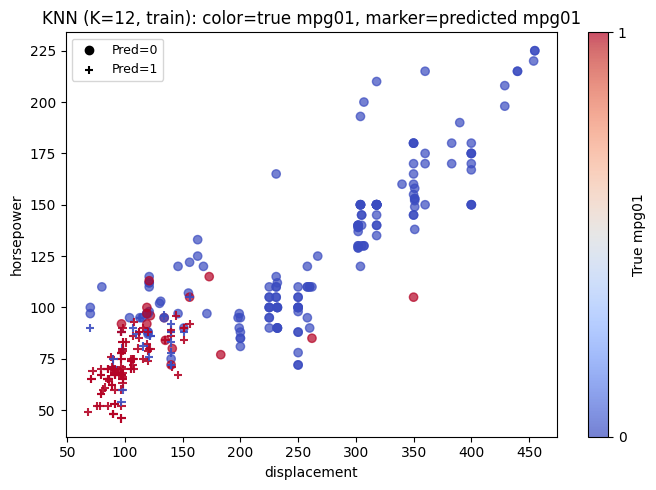

In [81]:
k_use = best_k  

knn_best = KNeighborsClassifier(n_neighbors=k_use)
knn_best.fit(X_train_s, y_train)   # uses standardized arrays from 7(i)

y_pred_train_knn = knn_best.predict(X_train_s)
y_pred_test_knn = knn_best.predict(X_test_s)

knn_misclass_train = 1.0 - accuracy_score(y_train, y_pred_train_knn)
knn_misclass_test = 1.0 - accuracy_score(y_test, y_pred_test_knn)

print(f"KNN Training Misclassification Rate: {knn_misclass_train:.4f}")
print(f"KNN Test Misclassification Rate: {knn_misclass_test:.4f}")

# scatterplot (same xvar/yvar as part d): color=true via colorbar, marker=predicted
x = x_train_auto[xvar].to_numpy()
y_ = x_train_auto[yvar].to_numpy()
true = y_train
pred = y_pred_train_knn

plt.figure(figsize=(7, 5))
m0, m1 = pred == 0, pred == 1

sc = plt.scatter(x[m0], y_[m0], c=true[m0], cmap="coolwarm", vmin=0, vmax=1, marker="o", alpha=0.7)
plt.scatter(x[m1], y_[m1], c=true[m1], cmap="coolwarm", vmin=0, vmax=1, marker="+", alpha=0.9)

plt.xlabel(xvar)
plt.ylabel(yvar)
plt.title(f"KNN (K={k_use}, train): color=true mpg01, marker=predicted mpg01")
plt.colorbar(sc, ticks=[0, 1], label="True mpg01")
plt.scatter([], [], c="k", marker="o", label="Pred=0")
plt.scatter([], [], c="k", marker="+", label="Pred=1")
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [82]:
# Test assertions
assert 0.1 < knn_misclass_test < 0.25, f"Expected ~0.16, got {knn_misclass_test}"
print("All tests passed!")

All tests passed!


---

**Problem 7 (k):** KNN Probability Estimation

Using your fitted KNN model, estimate the probability of a car having `mpg` above 25 if its values for the four predictors are all at the corresponding median values in the training dataset. Store this probability in a variable called `prob_median_knn`.

In [83]:
# Problem 7(k): KNN probability at median predictor values (use SAME scaling as 7(i)/(j))
# median (on training data, original scale)
x_median = x_train_auto[knn_features].median().to_numpy()   # shape (4,)

# standardize using the SAME mu, sd you computed for KNN
x_median_s = ((x_median - mu) / sd).reshape(1, -1)          # shape (1, 4)

# probability for class mpg01 = 1
class1_col = list(knn_best.classes_).index(1)  # knn_best from 7(j)
prob_median_knn = float(knn_best.predict_proba(x_median_s)[0, class1_col])

print(f"Probability of mpg > 25 at median predictor values (KNN): {prob_median_knn:.4f}")

Probability of mpg > 25 at median predictor values (KNN): 0.7500


In [84]:
# Test assertions
assert 0 <= prob_median_knn <= 1, "Probability should be between 0 and 1"
print("All tests passed!")

All tests passed!


---

**Problem 7 (l):** Model Comparison Summary

Compare and contrast the performance of LDA, QDA, logistic regression, and KNN on this dataset. What do your results suggest about the distribution of the data? About the nature of the boundary between classes? Defend your conclusions using your findings from earlier in this problem.

Using the same train/test split and the same four predictors (`cylinders`, `displacement`, `weight`, `horsepower`), I compared LDA, QDA, logistic regression, and KNN. The resulting misclassification rates were:

$$
\begin{array}{lcc}
\hline
\text{Model} & \text{Train misclass} & \text{Test misclass}\\
\hline
\text{LDA} & 0.146965 & 0.202532\\
\text{QDA} & 0.137380 & 0.177215\\
\text{Logistic} & 0.121406 & 0.151899\\
\text{KNN }(K=12) & 0.124601 & 0.113924\\
\hline
\end{array}
$$

Overall, **KNN with $K=12$ performed best on the test set** (test misclassification $=0.113924$), followed by logistic regression ($0.151899$), QDA ($0.177215$), and LDA ($0.202532$). Training errors show a similar ranking, with KNN and logistic regression having the lowest training misclassification.

**What this suggests about the distribution and class boundary.**  
QDA improves over LDA on both training and test data ($0.137380$ vs.\ $0.146965$ train; $0.177215$ vs.\ $0.202532$ test), suggesting that the **equal within-class covariance assumption** behind LDA is likely somewhat violated (i.e., the two classes may have different spreads/covariances in the predictor space). That would make a purely linear LDA boundary less appropriate.

However, logistic regression (which also yields a **linear decision boundary** in the predictors) performs noticeably better than LDA (test $0.151899$ vs.\ $0.202532$). This indicates that a linear boundary is still a reasonable approximation, but LDA’s specific distributional assumptions (multivariate normality with a common covariance) may not hold well.

Finally, the fact that KNN achieves the lowest test error (test $0.113924$) suggests that allowing a **more flexible, potentially nonlinear** boundary provides a meaningful improvement. Since the best performance occurs at a moderate value $K=12$ (rather than extremely small $K$), the boundary likely has some nonlinearity but is not extremely jagged; smoothing across neighborhoods improves generalization.

**Connection to earlier findings.**  
The exploratory plots in part (b) showed strong separation between $\texttt{mpg01}=0$ and $\texttt{mpg01}=1$ for variables like `weight`, `horsepower`, `displacement`, and `cylinders`, which explains why all four methods perform better than chance. The scatterplots in parts (d)--(j) show noticeable separation with overlap, consistent with nonzero error rates and with KNN’s advantage when modest nonlinearity is present.

In [85]:
summary = pd.DataFrame(
    {
        "Train misclass": [lda_misclass_train, qda_misclass_train, logistic_misclass_train, knn_misclass_train],
        "Test misclass":  [lda_misclass_test,  qda_misclass_test,  logistic_misclass_test,  knn_misclass_test],
    },
    index=["LDA", "QDA", "Logistic", f"KNN (K={best_k})"],
)
display(summary)

,Train misclass,Test misclass
LDA,0.146965,0.202532
QDA,0.137380,0.177215
Logistic,0.121406,0.151899
KNN (K=12),0.124601,0.113924
